In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

print(os.listdir('/content/drive/MyDrive'))

['Snapchat-1429388362.jpg', 'IMG_20220322_142117_384.jpg', 'IMG_20220322_141947_872.jpg', 'IMG_20220225_150250_575.jpg', 'IMG_20220225_150248_041.jpg', 'IMG_20220225_150246_134.jpg', 'IMG_20220225_150243_901.jpg', 'IMG_20220102_210029_060.jpg', 'IMG_20211218_114122_132.jpg', 'IMG_20220322_142120_048.jpg', '208acc8c-1e2a-4238-8361-b4198da3a397.mp4', 'a8e4b022-64cb-4e36-9fc8-0374585235e4.mp4', '6374ff8d-04ab-49fb-8d69-db1ae2897525.jpg', 'IMG_1862.PNG', '968f8636-c90e-44c2-b5e6-6f027457a7f4.jpg', '6d8f8afa-4c08-4bd3-b39d-feb71816ec38.jpg', '9012aed0-5bba-4574-9856-68800c88bde9.jpg', '8d7dd70a-f569-4a62-8134-4321f1622b7c.jpg', '582184a6-b426-427c-8edf-d1b9150b5218.jpg', '21fbb7fe-0acf-462c-9136-6a25154e113f.jpg', '666a2d4a-48db-4324-b13b-a16cd26e951c.jpg', '288073dd-c1b2-4c47-977c-3866e6690a59.mp4', '8450b92b-a3b8-4579-ae27-e3edc55a2ed6.mp4', '0f7e3e35-99be-4f57-8589-41a87f34cb04.mp4', '86092cef-116d-4227-ac5e-ca214714b4fc.mp4', 'e65ee5e6-9f04-4c4f-8fd7-2d7eab20001c.mp4', '9a7ea962-cb6d-49

In [3]:
import zipfile
zip_path = "/content/drive/MyDrive/Mammo-Bench/Preprocessed_Dataset.zip"
extract_path = "/content/"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Unzipped successfully")

Unzipped successfully


In [4]:
import pandas as pd
DATA_ROOT = "/content"
CSV_PATH = "/content/drive/MyDrive/Mammo-Bench/metadata.csv"

df = pd.read_csv(CSV_PATH)

sample_path = df.iloc[0]["preprocessed_image_path"]
full_path = os.path.join(DATA_ROOT, sample_path)

print(full_path)
print(os.path.exists(full_path))

/content/Preprocessed_Dataset/inbreast/inbreast_0.jpg
True


In [5]:
print(df["classification"].value_counts())

classification
Malignant               8184
Benign                  6069
Normal                  5243
Suspicious Malignant     235
Name: count, dtype: int64


In [6]:
def map_label(label):
    if label == "Normal":
        return "Normal"
    elif label == "Benign":
        return "Benign"
    elif label in ["Malignant", "Suspicious Malignant"]:
        return "Malignant"

df["final_label"] = df["classification"].apply(map_label)

df.head()

,source_dataset,preprocessed_image_path,classification,density,BIRADS,mask_path,raw_image_path,laterality,view,source_subjectID,...,y,radius,abnormality id,calc type,calc distribution,subtlety,mass shape,mass margins,cropped_image_file_new,final_label
0,inbreast,Preprocessed_Dataset/inbreast/inbreast_0.jpg,Normal,D,1.0,Masks/inbreast/inbreast_0.jpg,Original_Dataset/inbreast/inbreast_0.jpg,R,CC,22678622,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Normal
1,inbreast,Preprocessed_Dataset/inbreast/inbreast_1.jpg,Benign,D,3.0,Masks/inbreast/inbreast_1.jpg,Original_Dataset/inbreast/inbreast_1.jpg,L,CC,22678646,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Benign
2,inbreast,Preprocessed_Dataset/inbreast/inbreast_2.jpg,Normal,D,1.0,Masks/inbreast/inbreast_2.jpg,Original_Dataset/inbreast/inbreast_2.jpg,R,MLO,22678670,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Normal
3,inbreast,Preprocessed_Dataset/inbreast/inbreast_3.jpg,Benign,D,3.0,Masks/inbreast/inbreast_3.jpg,Original_Dataset/inbreast/inbreast_3.jpg,L,MLO,22678694,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Benign
4,inbreast,Preprocessed_Dataset/inbreast/inbreast_4.jpg,Malignant,B,5.0,Masks/inbreast/inbreast_4.jpg,Original_Dataset/inbreast/inbreast_4.jpg,R,CC,22614074,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Malignant


In [7]:
label_map = {
    "Normal": 0,
    "Benign": 1,
    "Malignant": 2
}
revers_map = {
    0: "Normal",
    1: "Benign" ,
    2: "Malignant"
}
df["label_id"] = df["final_label"].map(label_map)

print(df[["classification", "final_label", "label_id"]].head())
print('\n')
print(df["final_label"].value_counts())

  classification final_label  label_id
0         Normal      Normal         0
1         Benign      Benign         1
2         Normal      Normal         0
3         Benign      Benign         1
4      Malignant   Malignant         2


final_label
Malignant    8419
Benign       6069
Normal       5243
Name: count, dtype: int64


In [8]:
df["full_image_path"] = df["preprocessed_image_path"].apply(
    lambda x: os.path.join(DATA_ROOT, x)
)
print(df['full_image_path'].iloc[0])

missing = df[~df["full_image_path"].apply(os.path.exists)]
print("Missing files:", len(missing))

columns_needed = [
    "full_image_path",
    "final_label",
    "label_id",
    'source_subjectID'
]

df = df[columns_needed].copy()

print(df.head())
print(df.shape)
print(df.columns)

/content/Preprocessed_Dataset/inbreast/inbreast_0.jpg
Missing files: 0
                                     full_image_path final_label  label_id  \
0  /content/Preprocessed_Dataset/inbreast/inbreas...      Normal         0   
1  /content/Preprocessed_Dataset/inbreast/inbreas...      Benign         1   
2  /content/Preprocessed_Dataset/inbreast/inbreas...      Normal         0   
3  /content/Preprocessed_Dataset/inbreast/inbreas...      Benign         1   
4  /content/Preprocessed_Dataset/inbreast/inbreas...   Malignant         2   

  source_subjectID  
0         22678622  
1         22678646  
2         22678670  
3         22678694  
4         22614074  
(19731, 4)
Index(['full_image_path', 'final_label', 'label_id', 'source_subjectID'], dtype='object')


In [9]:
from torch.utils.data import Dataset
from PIL import Image

class MammoBenchDataset (Dataset):
  def __init__(self,dataframe,transform=None):
    self.dataframe = dataframe.reset_index(drop=True)
    self.transform = transform

  def __len__(self):
    return (len(self.dataframe))

  def __getitem__ (self,idx):
    row = self.dataframe.iloc[idx]

    image_path = row['full_image_path']
    image_label = row['label_id']

    image = Image.open(image_path).convert("RGB")

    if self.transform:
      image = self.transform(image)

    return image, image_label


dataset = MammoBenchDataset(df)
print(f'Length of the dataset : {len(dataset)}')
img,label = dataset[12334]
print(f"Image type: {type(img)}")
print(f"Image Label: {label}")

Length of the dataset : 19731
Image type: <class 'PIL.Image.Image'>
Image Label: 2


In [10]:
from torchvision import transforms


train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean = [0.485, 0.456, 0.406],
        std = [0.229, 0.224, 0.225]
    )
]
)

val_test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean = [0.485, 0.456, 0.406],
        std = [0.229, 0.224, 0.225]
    )
])

In [11]:
dataset_with_transforms = MammoBenchDataset(df,transform=train_transform)

print(len(dataset_with_transforms))
img, label = dataset_with_transforms [0]
print(type(img))
print(img.shape)
print(label)

19731
<class 'torch.Tensor'>
torch.Size([3, 224, 224])
0


In [12]:
import matplotlib.pyplot as plt
import numpy as np
def show_image(img, title=""):
    img = img.numpy().transpose((1, 2, 0))  # convert [C,H,W] → [H,W,C]
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")

def unnormalize(img):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    img = img.numpy().transpose((1, 2, 0))
    img = std * img + mean   # reverse normalization
    img = np.clip(img, 0, 1)
    return img

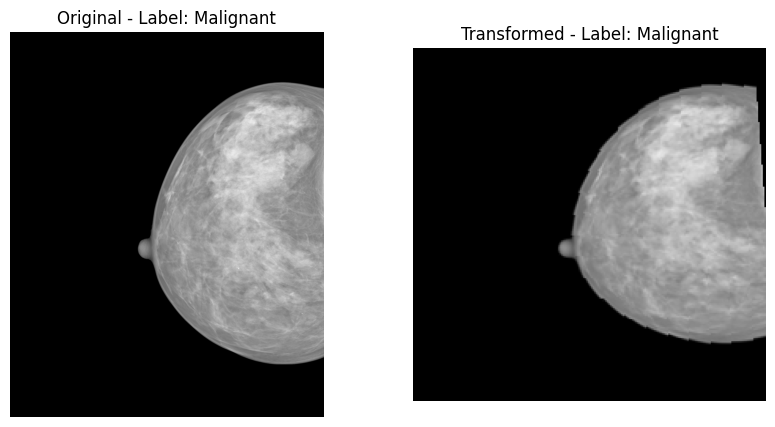

In [13]:
# dataset without transform
dataset_original = MammoBenchDataset(df)

# dataset with transform
dataset_transformed = MammoBenchDataset(df, transform=train_transform)

# get same sample
img_orig, label_orig = dataset_original[11]
img_trans, label_trans = dataset_transformed[11]

# plot side by side
plt.figure(figsize=(10,5))

label_orig = revers_map[label_orig]
label_trans = revers_map[label_trans]
# original
plt.subplot(1,2,1)
plt.imshow(img_orig)
plt.title(f"Original - Label: {label_orig}")
plt.axis("off")

# transformed
plt.subplot(1,2,2)
plt.imshow(unnormalize(img_trans))
plt.title(f"Transformed - Label: {label_trans}")
plt.axis("off")

plt.show()

In [14]:
from sklearn.model_selection import train_test_split

#print(df["final_label"].isnull().sum())
#print(df["label_id"].isnull().sum())
#print(df["full_image_path"].isnull().sum())

#print(df.columns)

subject_col = 'source_subjectID'
subjects = df['source_subjectID'].unique()
print ("\nTotal Unique Objects :", len(subjects))


train_subjects, temp_subjects = train_test_split(
    subjects,
    test_size=0.30,
    random_state=42
)

val_subjects, test_subjects = train_test_split(
    temp_subjects,
    test_size=0.50,
    random_state=42
)

print("Train subjects:", len(train_subjects))
print("Validation subjects:", len(val_subjects))
print("Test subjects:", len(test_subjects))



train_df = df[df[subject_col].isin(train_subjects)].copy()
val_df = df[df[subject_col].isin(val_subjects)].copy()
test_df = df[df[subject_col].isin(test_subjects)].copy()

print("\nImage counts")
print("Train images:", len(train_df))
print("Validation images:", len(val_df))
print("Test images:", len(test_df))



Total Unique Objects : 5860
Train subjects: 4102
Validation subjects: 879
Test subjects: 879

Image counts
Train images: 13796
Validation images: 2977
Test images: 2958


In [15]:
train_set = set(train_df[subject_col].unique())
val_set = set(val_df[subject_col].unique())
test_set = set(test_df[subject_col].unique())

print("\nOverlap check")
print("Train ∩ Val:", len(train_set.intersection(val_set)))
print("Train ∩ Test:", len(train_set.intersection(test_set)))
print("Val ∩ Test:", len(val_set.intersection(test_set)))


print("\nTrain class distribution:")
print(train_df["final_label"].value_counts())

print("\nValidation class distribution:")
print(val_df["final_label"].value_counts())

print("\nTest class distribution:")
print(test_df["final_label"].value_counts())


Overlap check
Train ∩ Val: 0
Train ∩ Test: 0
Val ∩ Test: 0

Train class distribution:
final_label
Malignant    5940
Benign       4277
Normal       3579
Name: count, dtype: int64

Validation class distribution:
final_label
Malignant    1236
Benign        909
Normal        832
Name: count, dtype: int64

Test class distribution:
final_label
Malignant    1243
Benign        883
Normal        832
Name: count, dtype: int64


In [16]:
from torch.utils.data import DataLoader
train_dataset = MammoBenchDataset(train_df,transform=train_transform)
val_dataset = MammoBenchDataset(val_df,transform=val_test_transform)
test_dataset = MammoBenchDataset(test_df,transform=val_test_transform)


print(" Length of train dataset:", len(train_dataset))
print(" Length of Validation dataset:", len(val_dataset))
print(" Length of test dataset:", len(test_dataset))

BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size = BATCH_SIZE,
    shuffle = True
)

val_loader = DataLoader(
    val_dataset,
    batch_size = BATCH_SIZE,
    shuffle = False
)

test_loader = DataLoader(
    test_dataset,
    batch_size = BATCH_SIZE,
    shuffle = False
)

print("DataLoaders created successfully.")

images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("First few labels:", labels[:10])

print(images.min(), images.max())


 Length of train dataset: 13796
 Length of Validation dataset: 2977
 Length of test dataset: 2958
DataLoaders created successfully.
Image batch shape: torch.Size([16, 3, 224, 224])
Label batch shape: torch.Size([16])
First few labels: tensor([1, 2, 0, 2, 2, 0, 1, 2, 1, 2])
tensor(-2.1179) tensor(2.6400)


In [17]:
import torch
import torch.nn as nn
from torchvision import models

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 86.2MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [19]:
for param in model.parameters():
    param.requires_grad = False


num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 3)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)

print(model.fc)

Using device: cpu
Linear(in_features=512, out_features=3, bias=True)


In [26]:
from tqdm import tqdm
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    loop = tqdm(dataloader, desc="Training")

    for images, labels in loop:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

        loop.set_postfix(loss=loss.item())

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [27]:
def validate_one_epoch(model, dataloader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)


            outputs = model(images)


            loss = criterion(outputs, labels)


            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [28]:
num_epochs = 1

best_val_loss = float("inf")
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc = validate_one_epoch(
        model, val_loader, criterion, device
    )

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    print("-" * 50)

    # save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_resnet18_mammobench.pth")
        print("Best model saved.")

Training: 100%|██████████| 863/863 [37:10<00:00,  2.58s/it, loss=0.811]


Epoch [1/1]
Train Loss: 0.8974 | Train Acc: 0.5620
Val Loss:   0.8433 | Val Acc:   0.6056
--------------------------------------------------
Best model saved.


In [29]:
def test_model(model, dataloader, device):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return all_preds, all_labels

In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# load best model (IMPORTANT)
#model.load_state_dict(torch.load("best_resnet18_mammobench.pth"))

model.load_state_dict(torch.load("/content/drive/MyDrive/Mammo-Bench/best_resnet18_mammobench.pth"))
model.eval()

# run test
y_pred, y_true = test_model(model, test_loader, device)

# metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("Test Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Test Accuracy: 0.6041244083840432
Precision: 0.6075609882027384
Recall: 0.6041244083840432
F1 Score: 0.5931806414936565


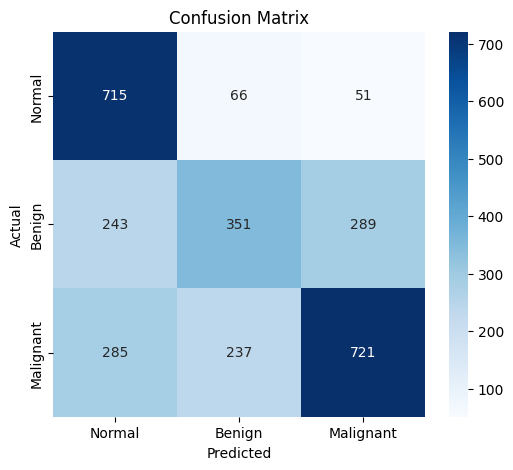

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal", "Benign", "Malignant"],
            yticklabels=["Normal", "Benign", "Malignant"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [34]:
#save_path = "/content/drive/MyDrive/Mammo-Bench/best_resnet18_mammobench.pth"

#torch.save(model.state_dict(), save_path)

#print("Model saved to Drive:", save_path)

Model saved to Drive: /content/drive/MyDrive/Mammo-Bench/best_resnet18_mammobench.pth


In [38]:
model_path = "/content/drive/MyDrive/Mammo-Bench/best_resnet18_mammobench.pth"

model.load_state_dict(torch.load(model_path))
model = model.to(device)
model.eval()

print("Model loaded successfully.")



Model loaded successfully.


In [65]:
class_names = ["Normal", "Benign", "Malignant"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# rebuild model
inference_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
num_features = inference_model.fc.in_features
inference_model.fc = nn.Linear(num_features, 3)

# load trained weights
model_path = "/content/drive/MyDrive/Mammo-Bench/best_resnet18_mammobench.pth"
inference_model.load_state_dict(torch.load(model_path, map_location=device))

inference_model = inference_model.to(device)
inference_model.eval()

def predict_single_image(image_path, model, transform, class_names, device):
    image = Image.open(image_path).convert("RGB")
    image = transform(image)
    image = image.unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(image)
        probabilities = torch.softmax(outputs, dim=1)
        predicted_class_idx = torch.argmax(probabilities, dim=1).item()

    predicted_class = class_names[predicted_class_idx]
    probability_scores = probabilities.cpu().numpy()[0]

    predicted_prob = probability_scores[predicted_class_idx]

    return predicted_class, predicted_prob

# test on one image
sample_image_path = df["full_image_path"].iloc[1222]

predicted_class, predicted_prob = predict_single_image(
    sample_image_path,
    inference_model,
    val_test_transform,
    class_names,
    device
)

print(f"Predicted class: {predicted_class}")
print(f"Confidence: {predicted_prob * 100:.2f}%")

Using device: cpu
Predicted class: Normal
Confidence: 84.93%
